# Chapter 34 Lab — Structural Equation and Path Models (Python)

In this lab you will build the core mediation-analysis workflow from scratch and fit a small path model — the observable-variable heart of structural equation modeling. The arc:

1. **Simulate** a brain-as-mediator dataset ($X \to M \to Y$ plus a direct path)
2. **Estimate the paths** $a$, $b$, $c'$, and $c$ with two regressions, and verify the decomposition $c = c' + ab$
3. **Bootstrap** a confidence interval and P value for the indirect effect $a \times b$
4. **Break the model**: show how an unmodeled confounder of the $M$–$Y$ relationship manufactures a spurious indirect effect — and how adjusting for it repairs the analysis
5. **Fit a three-node path model** (the recursive SEM of Figure 34.1) by regression equations, compare the model-implied covariance with the observed one, and test an individual edge

**How to run this notebook.** It runs anywhere — directly in your browser on the tutorial site, on Colab, or locally — using only numpy, pandas, scipy, and matplotlib (no downloads, all data simulated). Run cells top to bottom. For the concepts behind the code, see the [chapter page](https://torwager.github.io/elements-of-fmri-tutorials/book/part6/ch34-structural-equation-and-path-models).


**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)   # fix the random seed for reproducibility
np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.6 | pandas 3.0.5


## Step 1 — Simulate a brain-as-mediator dataset

We mimic the chapter's running example: a stressor manipulation $X$, brain activity in an ACC region as the mediator $M$, and stressor-evoked heart-rate increase as the outcome $Y$. One observation per participant (single-level mediation), $n = 200$.

The generative model *is* the mediation model, so we know the ground truth:

$$M_i = a\,X_i + e_{M,i}, \qquad Y_i = c'\,X_i + b\,M_i + e_{Y,i}$$

with true paths $a = 0.6$, $b = 0.5$, and direct effect $c' = 0.2$. The implied total effect is $c = c' + ab = 0.2 + 0.30 = 0.50$.

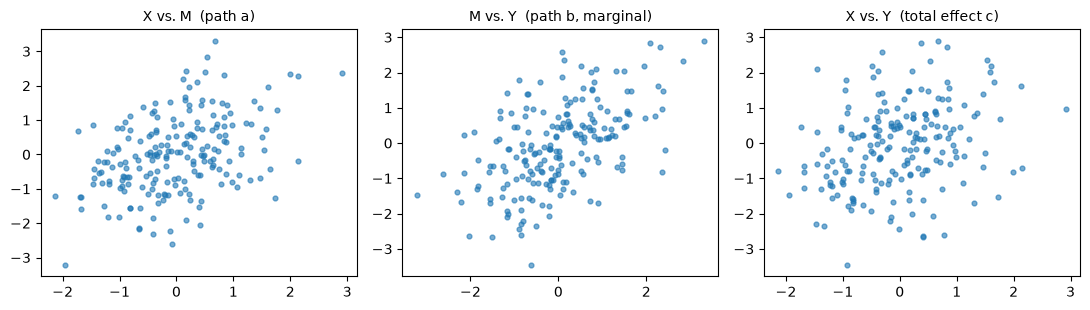

In [2]:
n = 200                                   # n = participants (one observation each)
a_true, b_true, cp_true = 0.6, 0.5, 0.2   # true paths: a (X->M), b (M->Y|X), c' (direct)

X = rng.standard_normal(n)                        # exposure (e.g., stressor intensity)
M = a_true * X + rng.standard_normal(n)           # mediator (e.g., ACC activity)
Y = cp_true * X + b_true * M + rng.standard_normal(n)  # outcome (e.g., heart rate)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, (u, v, lab) in zip(axes, [(X, M, "X vs. M  (path a)"),
                                  (M, Y, "M vs. Y  (path b, marginal)"),
                                  (X, Y, "X vs. Y  (total effect c)")]):
    ax.scatter(u, v, s=12, alpha=0.6)
    ax.set_title(lab, fontsize=10)
fig.tight_layout()
plt.show()

## Step 2 — Estimate the paths with two regressions

Path analysis on observed variables reduces to a *sequence of regressions*:

- **Path $a$** — slope of $M \sim X$
- **Paths $c'$ and $b$** — slopes of $Y \sim X + M$ (the full model)
- **Path $c$** — slope of $Y \sim X$ (the reduced model, total effect)

The decomposition $c = c' + ab$ holds *exactly* for OLS estimates — the indirect effect $\widehat{a}\widehat{b}$ equals $\widehat{c} - \widehat{c'}$ to machine precision.

In [3]:
def ols(y, *preds):
    """OLS coefficients (intercept first) for y ~ 1 + preds."""
    D = np.column_stack([np.ones(len(y)), *preds])
    return np.linalg.lstsq(D, y, rcond=None)[0]

a_hat = ols(M, X)[1]              # M ~ X
cp_hat, b_hat = ols(Y, X, M)[1:3] # Y ~ X + M
c_hat = ols(Y, X)[1]              # Y ~ X

paths = pd.DataFrame(
    {"true":     [a_true, b_true, cp_true, cp_true + a_true * b_true, a_true * b_true],
     "estimate": [a_hat,  b_hat,  cp_hat,  c_hat,                     a_hat * b_hat]},
    index=["a (X->M)", "b (M->Y|X)", "c' (direct)", "c (total)", "a*b (indirect)"])
print(paths.round(3))

print(f"\nDecomposition check: c - c' = {c_hat - cp_hat:.6f}  vs  a*b = {a_hat * b_hat:.6f}")

                true  estimate
a (X->M)         0.6     0.519
b (M->Y|X)       0.5     0.531
c' (direct)      0.2     0.130
c (total)        0.5     0.406
a*b (indirect)   0.3     0.275

Decomposition check: c - c' = 0.275401  vs  a*b = 0.275401


All five quantities land near their true values, and $\widehat{c} - \widehat{c'} = \widehat{a}\widehat{b}$ exactly. In the CANlab Mediation Toolbox, `mediation(X, Y, M, 'boot')` returns these same five numbers as the columns of `paths`: `[a  b  c'  c  a*b]`.

## Step 3 — Bootstrap inference for the indirect effect

To test $H_0\!: ab = 0$ we need the sampling distribution of $\widehat{a}\widehat{b}$. The product of two normal coefficients is *not* normal — it is skewed — which is why the normal-theory **Sobel test** is overconservative. The **bootstrap** sidesteps the approximation: resample participants with replacement, re-estimate $a \times b$ each time, and read the confidence interval and P value off the empirical distribution.

indirect a*b = 0.275
bootstrap:  95% CI [0.177, 0.387],  p = 0.0000
Sobel test: z = 4.83,  p = 1.38e-06


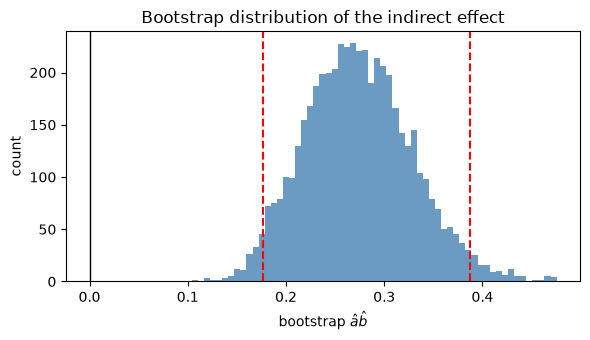

In [4]:
def boot_indirect(X, M, Y, n_boot=5000, seed=0):   # n_boot: ~5,000+ for stable CI tails
    """Percentile bootstrap distribution of the indirect effect a*b."""
    r = np.random.default_rng(seed)
    n = len(X)
    ab = np.empty(n_boot)
    for i in range(n_boot):
        idx = r.integers(0, n, n)              # resample cases with replacement
        ab[i] = ols(M[idx], X[idx])[1] * ols(Y[idx], X[idx], M[idx])[2]
    return ab

boot_ab = boot_indirect(X, M, Y)
lo, hi = np.percentile(boot_ab, [2.5, 97.5])
p_boot = 2 * min((boot_ab <= 0).mean(), (boot_ab >= 0).mean())

# Sobel test for comparison (normal-theory SE of the product)
def sobel(X, M, Y):
    n = len(X)
    a = ols(M, X)[1]
    se_a = np.sqrt(np.sum((M - ols(M, X)[0] - a * X) ** 2) / (n - 2) / np.sum((X - X.mean()) ** 2))
    D = np.column_stack([np.ones(n), X, M])
    beta = np.linalg.lstsq(D, Y, rcond=None)[0]
    resid = Y - D @ beta
    covb = np.sum(resid ** 2) / (n - 3) * np.linalg.inv(D.T @ D)
    b, se_b = beta[2], np.sqrt(covb[2, 2])
    z = a * b / np.sqrt(a**2 * se_b**2 + b**2 * se_a**2)
    return a * b, z, 2 * stats.norm.sf(abs(z))

ab_est, z_sobel, p_sobel = sobel(X, M, Y)
print(f"indirect a*b = {ab_est:.3f}")
print(f"bootstrap:  95% CI [{lo:.3f}, {hi:.3f}],  p = {p_boot:.4f}")
print(f"Sobel test: z = {z_sobel:.2f},  p = {p_sobel:.2e}")

plt.figure(figsize=(6, 3.5))
plt.hist(boot_ab, bins=60, color="steelblue", alpha=0.8)
plt.axvline(0, color="k", lw=1)
plt.axvline(lo, color="r", ls="--"); plt.axvline(hi, color="r", ls="--")
plt.xlabel("bootstrap $\\hat{a}\\hat{b}$"); plt.ylabel("count")
plt.title("Bootstrap distribution of the indirect effect")
plt.tight_layout(); plt.show()

The confidence interval excludes zero decisively — as it should, since the data contain true mediation. Note the mild right skew of the bootstrap distribution: this is exactly the feature the Sobel normal approximation ignores. (The CANlab toolbox refines the percentile interval further with bias-corrected, accelerated bootstrapping.)

## Step 4 — An unmodeled confounder creates spurious mediation

Now the cautionary tale. The causal interpretation of $a \times b$ requires **no unmodeled confounding** of the $M$–$Y$ relationship. Randomizing $X$ protects paths $a$ and $c$, but the mediator is only *observed* — so a lurking variable $U$ (say, general arousal) that raises both ACC activity and heart rate can create a $b$ path out of thin air.

We simulate a world with **no true mediation at all**: $M$ does not influence $Y$ ($b = 0$). Instead, $U$ drives both.

In [5]:
# Ground truth: X affects M and Y, but M has NO effect on Y (b = 0).
# A confounder U (e.g., arousal) affects both M and Y.
U  = rng.standard_normal(n)
M2 = 0.6 * X + 0.7 * U + rng.standard_normal(n)          # a = 0.6, confounded
Y2 = 0.3 * X + 0.0 * M2 + 0.7 * U + rng.standard_normal(n)  # true b = 0 !

# Naive mediation analysis (U unmeasured / ignored):
boot_naive = boot_indirect(X, M2, Y2, seed=1)
lo1, hi1 = np.percentile(boot_naive, [2.5, 97.5])
ab_naive = ols(M2, X)[1] * ols(Y2, X, M2)[2]
print(f"NAIVE  : a*b = {ab_naive:.3f}, 95% CI [{lo1:.3f}, {hi1:.3f}]"
      f"  ->  {'SPURIOUS mediation!' if lo1 > 0 or hi1 < 0 else 'ns'}")

# Correct analysis: include U as a covariate in both path regressions
a_adj  = ols(M2, X, U)[1]
b_adj  = ols(Y2, X, M2, U)[2]
r2 = np.random.default_rng(2)
boot_adj = np.empty(5000)
for i in range(5000):
    idx = r2.integers(0, n, n)
    boot_adj[i] = ols(M2[idx], X[idx], U[idx])[1] * ols(Y2[idx], X[idx], M2[idx], U[idx])[2]
lo2, hi2 = np.percentile(boot_adj, [2.5, 97.5])
print(f"ADJUSTED for U: a*b = {a_adj * b_adj:.3f}, 95% CI [{lo2:.3f}, {hi2:.3f}]"
      f"  ->  {'still significant' if lo2 > 0 or hi2 < 0 else 'no mediation (correct!)'}")

NAIVE  : a*b = 0.199, 95% CI [0.112, 0.304]  ->  SPURIOUS mediation!
ADJUSTED for U: a*b = -0.000, 95% CI [-0.076, 0.079]  ->  no mediation (correct!)


The naive analysis "detects" a significant indirect effect even though $M$ has zero causal effect on $Y$: the confounder induces an $M$–$Y$ partial correlation, and the machinery happily multiplies it by $a$. Adding $U$ as a covariate (the `'covs'` option in `mediation.m`) recovers the truth. In real data $U$ is usually *unmeasured* — which is why the chapter frames fMRI mediation as pathway discovery, not causal proof.

## Step 5 — A three-node path model fit by regression equations

Finally, the recursive SEM of Figure 34.1: ROI 1 drives ROIs 2 and 3 ($b_{12}$, $b_{13}$), and ROI 2 drives ROI 3 ($b_{23}$). In matrix form $y = B y + \zeta$, and because the model is recursive (no loops), each equation can be estimated by OLS:

- ROI 2 $\sim$ ROI 1 $\;\Rightarrow\; b_{12}$
- ROI 3 $\sim$ ROI 1 + ROI 2 $\;\Rightarrow\; b_{13}, b_{23}$

We then rebuild $B$, form the model-implied covariance $\Sigma(\theta) = (I-B)^{-1}\Psi(I-B)^{-T}$, and compare it with the sample covariance — the quantity SEM software minimizes. (Note the mediation model of Steps 1–3 is exactly this graph with ROI 1 = $X$, ROI 2 = $M$, ROI 3 = $Y$.)

In [6]:
# Simulate T time points from the recursive path model (true edges below)
T = 300                                      # T = time points in the simulated series
b12_true, b13_true, b23_true = 0.8, 0.4, 0.5 # true path coefficients for the three edges

z = rng.standard_normal((3, T))          # independent errors zeta, unit variance
y1 = z[0]
y2 = b12_true * y1 + z[1]
y3 = b13_true * y1 + b23_true * y2 + z[2]
Ydat = np.vstack([y1, y2, y3])           # 3 x T

# Fit each structural equation by OLS
b12_hat = ols(y2, y1)[1]
b13_hat, b23_hat = ols(y3, y1, y2)[1:3]
print(f"path estimates: b12 = {b12_hat:.3f} (true {b12_true}), "
      f"b13 = {b13_hat:.3f} (true {b13_true}), b23 = {b23_hat:.3f} (true {b23_true})")

# Rebuild B and the model-implied covariance Sigma = (I-B)^-1 Psi (I-B)^-T
B = np.array([[0,       0,       0],
              [b12_hat, 0,       0],
              [b13_hat, b23_hat, 0]])
resid_var = np.array([np.var(y1, ddof=1),
                      np.var(y2 - b12_hat * y1, ddof=2),
                      np.var(y3 - b13_hat * y1 - b23_hat * y2, ddof=3)])
Psi   = np.diag(resid_var)
IminB = np.eye(3) - B
Sigma_model = np.linalg.inv(IminB) @ Psi @ np.linalg.inv(IminB).T
Sigma_obs   = np.cov(Ydat)

print("\nobserved covariance:\n", Sigma_obs.round(3))
print("model-implied covariance:\n", Sigma_model.round(3))
print(f"max |difference| = {np.abs(Sigma_obs - Sigma_model).max():.4f}")

path estimates: b12 = 0.788 (true 0.8), b13 = 0.414 (true 0.4), b23 = 0.489 (true 0.5)

observed covariance:
 [[1.116 0.879 0.892]
 [0.879 1.742 1.216]
 [0.892 1.216 1.911]]
model-implied covariance:
 [[1.116 0.879 0.892]
 [0.879 1.746 1.218]
 [0.892 1.218 1.918]]
max |difference| = 0.0072


The model-implied and observed covariances agree almost perfectly — with 3 variables and 6 free parameters (3 paths + 3 error variances) matching 6 covariance moments, this model is *just-identified*: it can always reproduce the data covariance, so overall fit cannot be tested. Fit tests need over-identified models with fewer parameters than moments.

We *can*, however, test an individual **edge** by model comparison: does the direct ROI 1 → ROI 3 connection ($b_{13}$) improve the model beyond the indirect route through ROI 2? Dropping the edge gives a nested model, and for a single OLS-estimated path this likelihood-ratio-style comparison reduces to the familiar t-test on $b_{13}$.

In [7]:
# Test the ROI1 -> ROI3 edge: full model (y3 ~ y1 + y2) vs. reduced (y3 ~ y2)
D_full = np.column_stack([np.ones(T), y1, y2])
D_red  = np.column_stack([np.ones(T), y2])
beta_f = np.linalg.lstsq(D_full, y3, rcond=None)[0]
sse_f  = np.sum((y3 - D_full @ beta_f) ** 2)
beta_r = np.linalg.lstsq(D_red, y3, rcond=None)[0]
sse_r  = np.sum((y3 - D_red @ beta_r) ** 2)

F  = (sse_r - sse_f) / 1 / (sse_f / (T - 3))     # nested model comparison
pF = stats.f.sf(F, 1, T - 3)
print(f"edge b13: F(1, {T - 3}) = {F:.2f}, p = {pF:.2e}"
      f"  ->  the direct ROI1->ROI3 connection {'improves' if pF < .05 else 'does not improve'} the model")

edge b13: F(1, 297) = 36.20, p = 5.22e-09  ->  the direct ROI1->ROI3 connection improves the model


## Wrap-up

You built the full path-modeling toolkit for observed variables: estimating path coefficients with regressions, decomposing total effects into direct and indirect parts, bootstrapping the skewed product $a \times b$, and testing edges by nested model comparison against the model-implied covariance. You also saw the framework's Achilles heel — an unmodeled $M$–$Y$ confounder is indistinguishable from true mediation in observational data.

In MATLAB, the [CANlab Mediation Toolbox](https://github.com/canlab/MediationToolbox) wraps this workflow in `mediation.m` (with bias-corrected bootstrap, robust regression, multilevel models, and moderated mediation) and scales it to whole-brain search with `mediation_brain.m`. Return to the [chapter page](https://torwager.github.io/elements-of-fmri-tutorials/book/part6/ch34-structural-equation-and-path-models) for the conceptual context, and see Chapter 35 for dynamic causal models, which build directionality into a biophysical generative model rather than a covariance structure.